In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun
from utils.Plotter import Plotter as plotterfun
from utils.general_stats import GeneralStats



In [ ]:
data_handler = datafun(data=None)  # Pass any initial data if needed

info_dir = 'W:\Connie/results\Bassi2025\data'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)

#remove datasets for now while some are still running - finished: 0,1,2,3,4,5,6,7,11,14
# Indices to remove (example: remove datasets at indices 0 and 2)
remove_indices = list(set(range(0,25)) - set([0,1,2,3,4,5,6,7,11,14])) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]


model_type = 'GLM_3nmf_pre'
results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5]) #1-4 to load 10
model_type = 'GLM_3nmf_passive'
results_pass = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5])

dir = os.path.join('W:\Connie/results\Bassi2025\data')
#load significant sound/opto neurons
opto, sound, mouse_dates, significant_neurons, mod_indices = data_handler.load_sound_opto_data(dir, set_diff = True, exclude = "HE1-00_2023-05-30")

Processing dataset: HA11-1R_2023-05-05
poss_model_5_data_cluster_0.pkl
poss_model_5_data_cluster_1.pkl
poss_model_5_data_cluster_2.pkl
poss_model_5_data_cluster_3.pkl
poss_model_5_data_cluster_4.pkl
poss_model_5_data_cluster_5.pkl
poss_model_5_data_cluster_6.pkl
poss_model_5_data_cluster_7.pkl
poss_model_5_data_cluster_8.pkl
poss_model_5_data_cluster_9.pkl
poss_model_5_data_cluster_10.pkl
poss_model_5_data_cluster_11.pkl
poss_model_5_data_cluster_12.pkl
poss_model_5_data_cluster_13.pkl
poss_model_5_data_cluster_14.pkl
poss_model_5_data_cluster_15.pkl
poss_model_5_data_cluster_16.pkl
poss_model_5_data_cluster_17.pkl
poss_model_5_data_cluster_18.pkl
poss_model_5_data_cluster_19.pkl
poss_model_5_data_cluster_20.pkl
poss_model_5_data_cluster_21.pkl
poss_model_5_data_cluster_22.pkl
poss_model_5_data_cluster_23.pkl
poss_model_5_data_cluster_24.pkl
poss_model_5_data_cluster_25.pkl
poss_model_5_data_cluster_26.pkl
poss_model_5_data_cluster_27.pkl
poss_model_5_data_cluster_28.pkl
poss_model_5_d

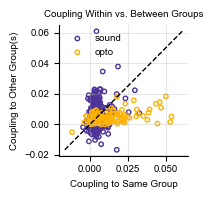

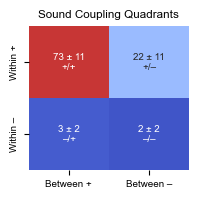

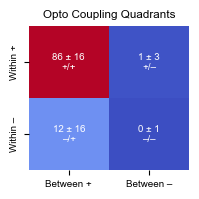

Permutation test p-value: 0, observed stat: 0.448
sound: p=0.0258, stat=0.000
opto: p=0.0002, stat=0.008
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


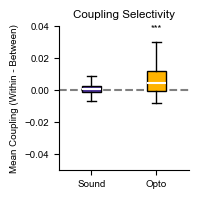

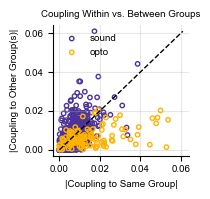

sound: p=0.7025, stat=-0.000
opto: p=0.0002, stat=0.008
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


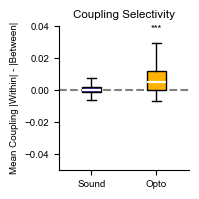

In [ ]:
all_results = results_pass
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive/' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)

#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}.pdf', #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=save_results,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90
)

p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.05,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}.pdf',
    mode = mode
)

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.05,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}.pdf')

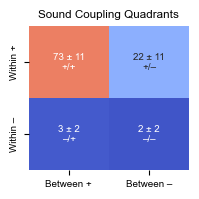

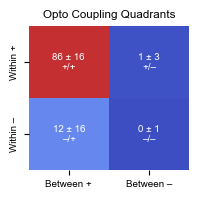

In [8]:
coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = 'mean', groups_to_plot = ['sound','opto'])

quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=None,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'coolwarm'
)